In [2]:
import pandas as pd
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=';')

In [4]:
wine.head()
wine.info()
wine.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [9]:
#handling missing values
wine.isnull().sum()
wine = wine.dropna()

In [10]:
print(wine.columns)
x = wine['alcohol']       # feature
y = wine['quality']       # target

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


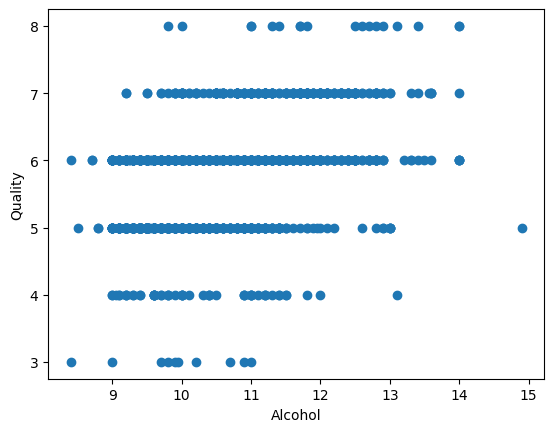

In [11]:
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

x = wine[['alcohol']]   # feature (2D)
y = wine['quality']     # target

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

##NO FEATURE SCALELNG REQUIRED

In [13]:
#but we will use the Standardization here
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)



In [17]:
import numpy as np

# Convert to 1D numpy arrays
x_train_flat = np.ravel(x_train)
x_test_flat = np.ravel(x_test)
y_train_flat = np.ravel(y_train)

# Formula for w and b (least squares)
w = np.sum((x_train_flat - x_train_flat.mean()) * (y_train_flat - y_train_flat.mean())) / \
    np.sum((x_train_flat - x_train_flat.mean())**2)

b = y_train_flat.mean() - w * x_train_flat.mean()

print("w =", w)
print("b =", b)

# Predict
y_pred = w * x_test_flat + b

w = 0.3812574679864861
b = 5.623924941360438


In [18]:
y_pred = w * x_test_flat + b

# Manual MSE
m = len(y_test)   # number of samples
mse = np.sum((y_test - y_pred)**2) / m

print("MSE =", mse)

MSE = 0.4995281340730444


Epoch 0: MSE = 32.2791, w = 0.0076, b = 0.1125
Epoch 100: MSE = 1.0641, w = 0.3317, b = 4.8930
Epoch 200: MSE = 0.5151, w = 0.3747, b = 5.5270
Epoch 300: MSE = 0.5054, w = 0.3804, b = 5.6111
Epoch 400: MSE = 0.5052, w = 0.3811, b = 5.6222
Epoch 500: MSE = 0.5052, w = 0.3812, b = 5.6237
Epoch 600: MSE = 0.5052, w = 0.3813, b = 5.6239
Epoch 700: MSE = 0.5052, w = 0.3813, b = 5.6239
Epoch 800: MSE = 0.5052, w = 0.3813, b = 5.6239
Epoch 900: MSE = 0.5052, w = 0.3813, b = 5.6239

Final: ŷ = 0.38·x + 5.62


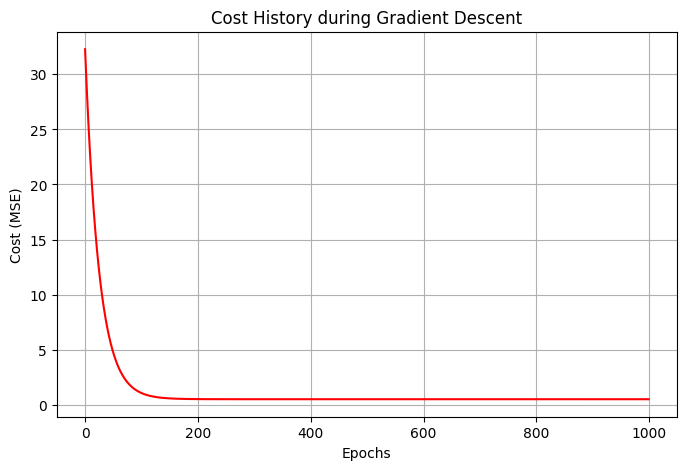

In [21]:
x = np.ravel(x_train)
y = np.ravel(y_train)
m = len(y)

# Initialize
w = 0.0
b = 0.0
learning_rate = 0.01
epochs = 1000

# Gradient Descent loop
for i in range(epochs):
    # 1. Predict
    y_pred = w * x + b

    # 2. Compute gradients (derivatives)
    dw = (2/m) * np.sum((y_pred - y) * x)
    db = (2/m) * np.sum(y_pred - y)

    # 3. Update weights
    w = w - learning_rate * dw
    b = b - learning_rate * db

    # Print every 100 steps
    if i % 100 == 0:
        mse = np.mean((y_pred - y)**2)
        print(f"Epoch {i}: MSE = {mse:.4f}, w = {w:.4f}, b = {b:.4f}")

print(f"\nFinal: ŷ = {w:.2f}·x + {b:.2f}")

# Plot cost history
plt.figure(figsize=(8,5))
plt.plot(cost_history, color='red')
plt.xlabel('Epochs')
plt.ylabel('Cost (MSE)')
plt.title('Cost History during Gradient Descent')
plt.grid(True)
plt.show()

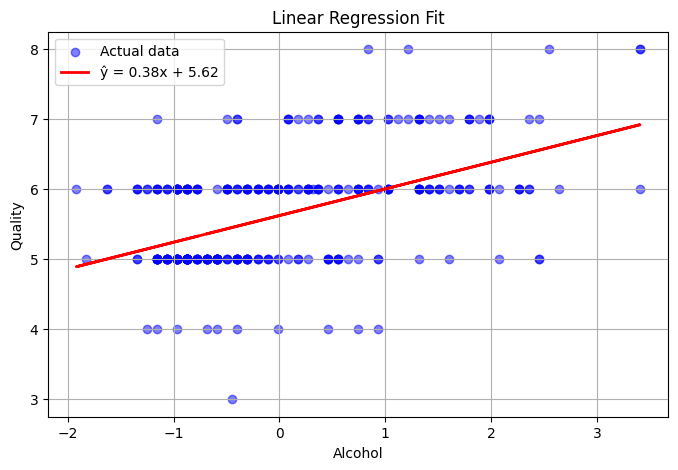

In [22]:
x_plot = np.ravel(x_test)
y_actual = np.ravel(y_test)
y_pred = w * x_plot + b

# Plot
plt.figure(figsize=(8,5))
plt.scatter(x_plot, y_actual, color='blue', alpha=0.5, label='Actual data')
plt.plot(x_plot, y_pred, color='red', linewidth=2, label=f'ŷ = {w:.2f}x + {b:.2f}')
plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
x_test_flat = np.ravel(x_test)
y_test_flat = np.ravel(y_test)
y_pred = w * x_test_flat + b

# MSE
m = len(y_test_flat)
mse = np.sum((y_test_flat - y_pred)**2) / m

# RMSE
rmse = np.sqrt(mse)

print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")

MSE  = 0.4995
RMSE = 0.7068


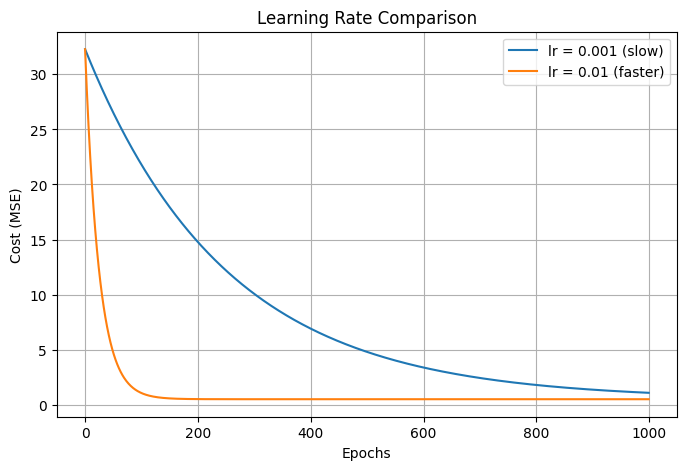

lr=0.001 → ŷ = 0.33x + 4.86, Final MSE = 1.0872
lr=0.01  → ŷ = 0.38x + 5.62, Final MSE = 0.5052


In [24]:
m = len(y)

def gradient_descent(lr, epochs=1000):
    w, b = 0.0, 0.0
    history = []
    for i in range(epochs):
        y_pred = w * x + b
        dw = (2/m) * np.sum((y_pred - y) * x)
        db = (2/m) * np.sum(y_pred - y)
        w = w - lr * dw
        b = b - lr * db
        history.append(np.mean((y_pred - y)**2))
    return w, b, history

# Two learning rates
w1, b1, h1 = gradient_descent(0.001)   # slow
w2, b2, h2 = gradient_descent(0.01)    # normal

# Plot both
plt.figure(figsize=(8,5))
plt.plot(h1, label='lr = 0.001 (slow)')
plt.plot(h2, label='lr = 0.01 (faster)')
plt.xlabel('Epochs')
plt.ylabel('Cost (MSE)')
plt.title('Learning Rate Comparison')
plt.legend()
plt.grid(True)
plt.show()

print(f"lr=0.001 → ŷ = {w1:.2f}x + {b1:.2f}, Final MSE = {h1[-1]:.4f}")
print(f"lr=0.01  → ŷ = {w2:.2f}x + {b2:.2f}, Final MSE = {h2[-1]:.4f}")
